In [33]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import math

## Purpose of the Code

Preprocesses all raw data into analysis-ready series:
- **Load & clean data:** Handle custom CSV formats
- **Transform variables:** QoQ_change_annual / MoM_change / level_change
- **Validate visually:** Plot levels vs. transformed series
- **Finalize datasets:** Export cleaned features as CSV
- **Combined dataset:** Export unified dataset with all series aligned to a quarterly frequency and missing values imputed

## construction_value_added

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/845271254.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


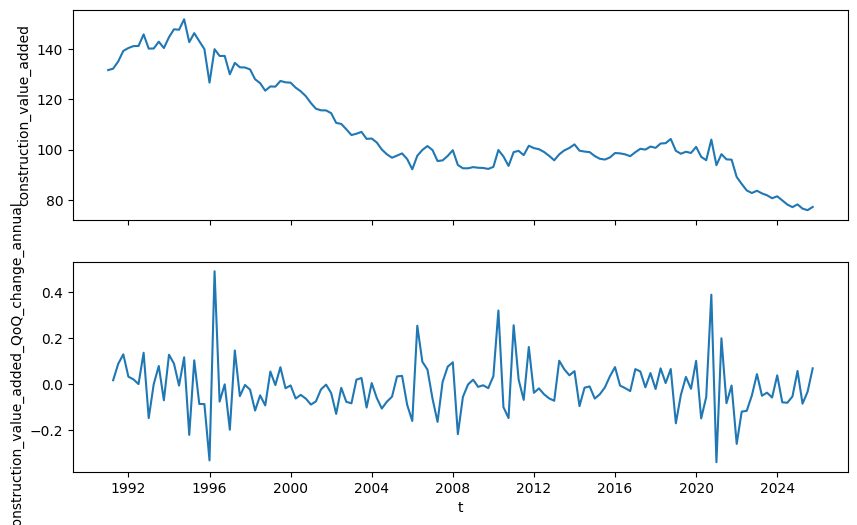

In [34]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/construction_value_added.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'construction_value_added'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['construction_value_added_QoQ_change_annual'] = (df['construction_value_added'] / df['construction_value_added'].shift(1))**4 - 1

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'construction_value_added')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'construction_value_added_QoQ_change_annual')

df = df.drop(columns = 'construction_value_added')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/construction_value_added_QoQ_change_annual.csv', index=False)

## construction

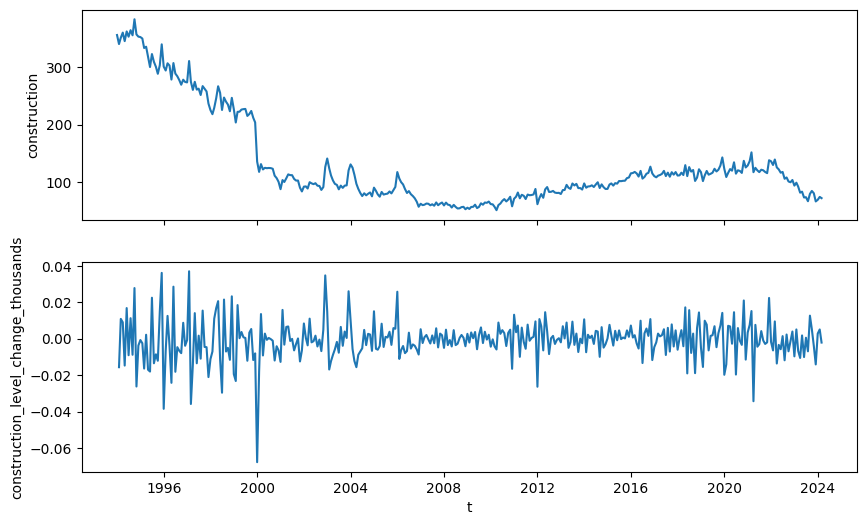

In [35]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/construction.csv',
                 header=None,
                 skiprows=1,
                 names=['t', 'construction']
                 )
df['t'] = pd.to_datetime(df['t'])
df['construction_level_change_thousands'] = df['construction'].diff() / 1000

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'construction')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'construction_level_change_thousands')

df = df.drop(columns = 'construction')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/construction_level_change_thousands.csv', index=False)

## disposable_personal

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/1672108317.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


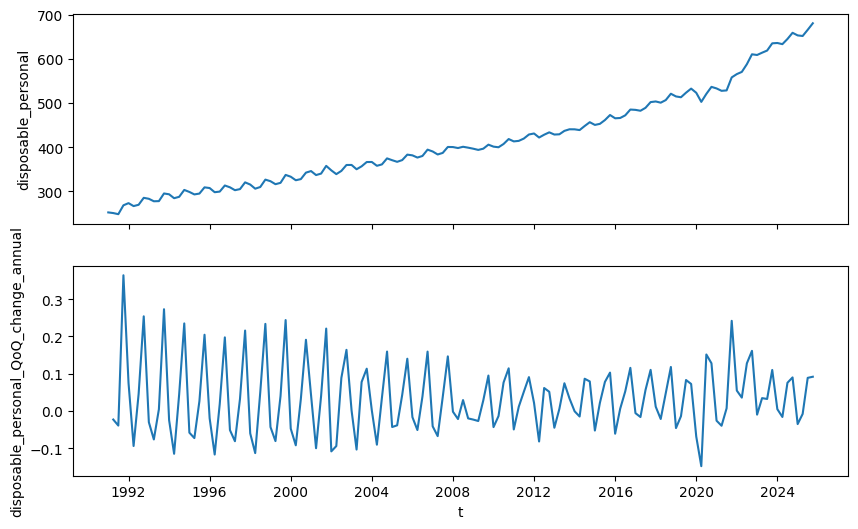

In [36]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/disposable_personal.csv',
                 header=None,
                 skiprows=8,
                 usecols=[0, 1],
                 names=['t', 'disposable_personal'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['disposable_personal_QoQ_change_annual'] = (df['disposable_personal'] / df['disposable_personal'].shift(1))**4 - 1

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'disposable_personal')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'disposable_personal_QoQ_change_annual')

df = df.drop(columns = 'disposable_personal')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/disposable_personal_QoQ_change_annual.csv', index=False)

## employees

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/1046208887.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


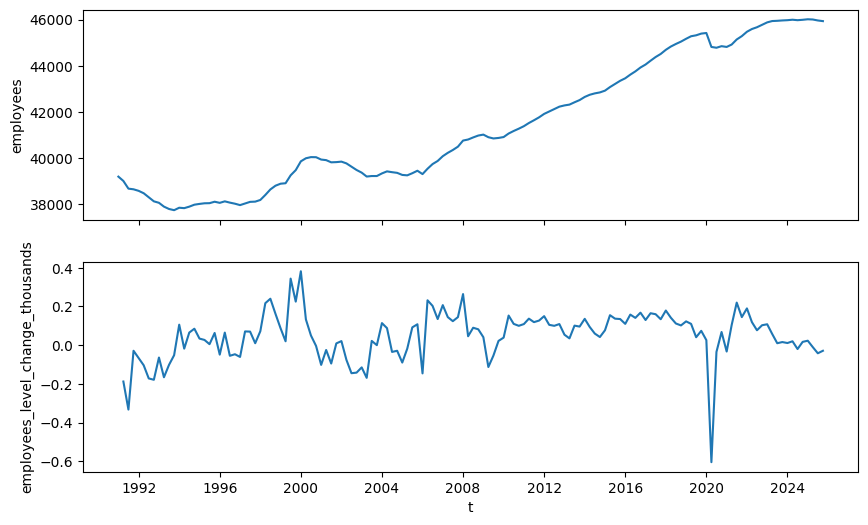

In [37]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/employees.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'employees'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['employees_level_change_thousands'] = df['employees'].diff() / 1000

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'employees')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'employees_level_change_thousands')

df = df.drop(columns = 'employees')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/employees_level_change_thousands.csv', index=False)

## export_price_index

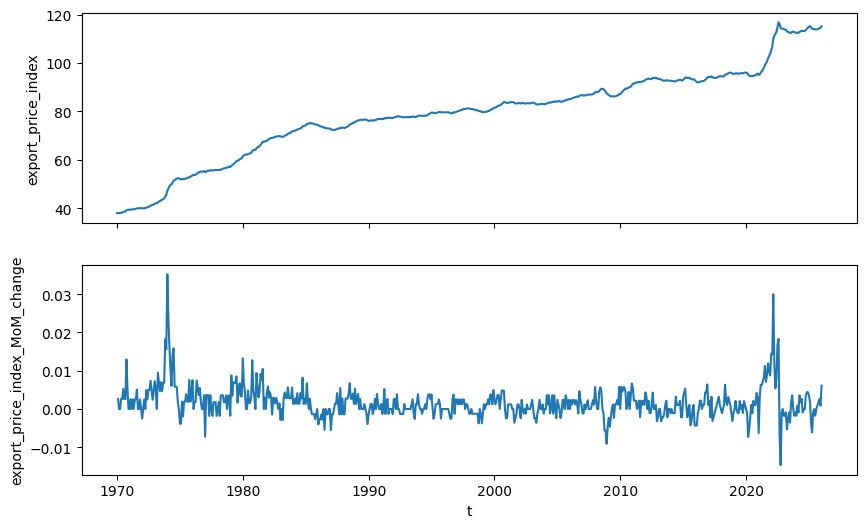

In [38]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/export_price_index.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'export_price_index'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['export_price_index_MoM_change'] = df['export_price_index'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'export_price_index')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'export_price_index_MoM_change')

df = df.drop(columns = 'export_price_index')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/export_price_index_MoM_change.csv', index=False)

## exports

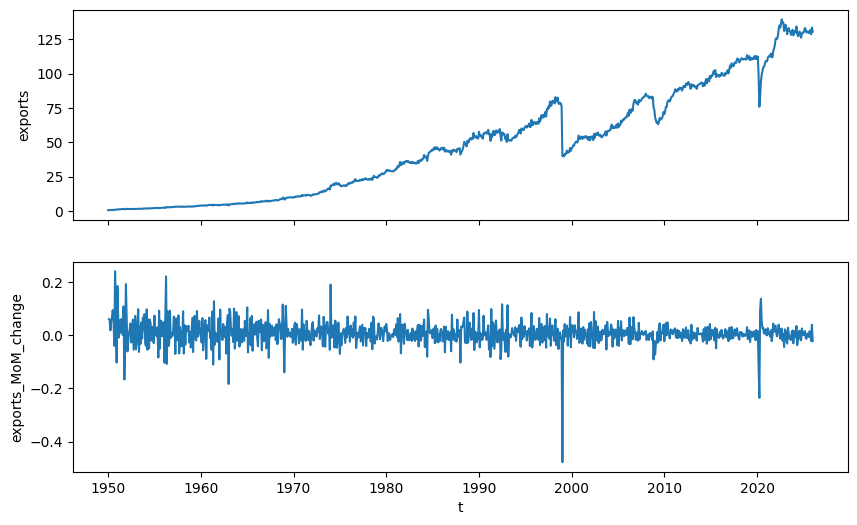

In [39]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/exports.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'exports'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['exports_MoM_change'] = df['exports'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'exports')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'exports_MoM_change')

df = df.drop(columns = 'exports')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/exports_MoM_change.csv', index=False)

## GDI

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/3682084884.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


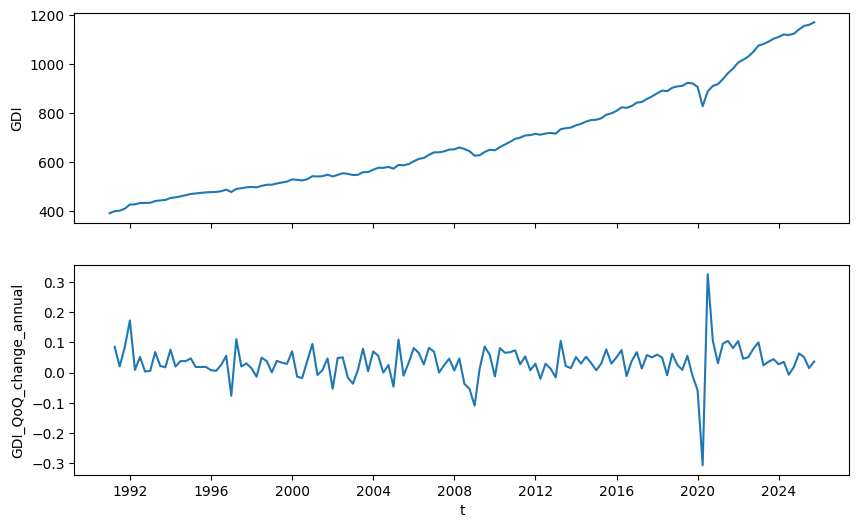

In [40]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/GDI.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'GDI'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['GDI_QoQ_change_annual'] = (df['GDI'] / df['GDI'].shift(1))**4 - 1

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'GDI')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'GDI_QoQ_change_annual')

df = df.drop(columns = 'GDI')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/GDI_QoQ_change_annual.csv', index=False)

## GDP

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/3266581063.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


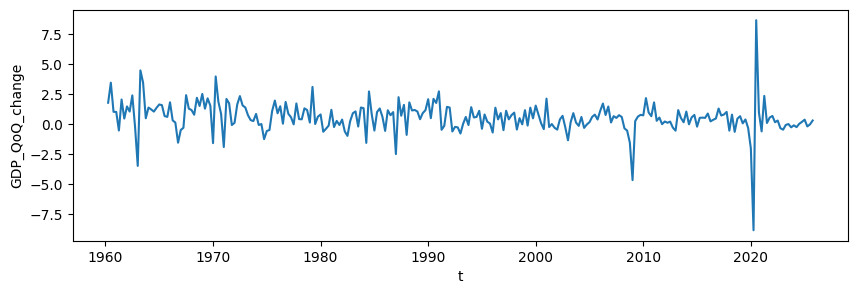

In [41]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/GDP.csv',
                 header=None,
                 skiprows=1,
                 usecols=[26, 30, 32],
                 names=['variable', 't', 'GDP_QoQ_change'])
df = df[df['variable'] == 'G1']
df['t'] = pd.to_datetime(df['t'])
df = df.sort_values(by = 't')

plt.figure(figsize = (10, 3))
sns.lineplot(data = df, x = 't', y = 'GDP_QoQ_change')

df = df.drop(columns = 'variable')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/GDP_QoQ_change.csv', index=False)

## HVPI_wo_food_energy

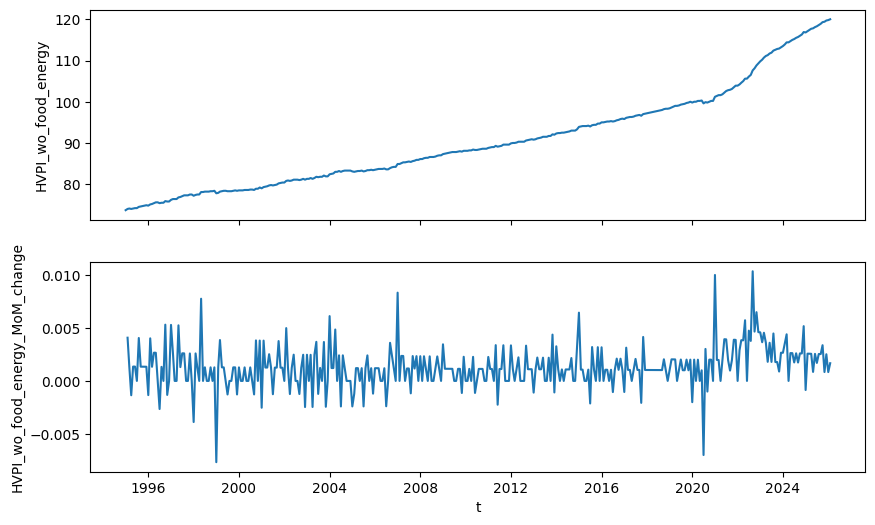

In [42]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/HVPI_wo_food_energy.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'HVPI_wo_food_energy'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['HVPI_wo_food_energy_MoM_change'] = df['HVPI_wo_food_energy'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'HVPI_wo_food_energy')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'HVPI_wo_food_energy_MoM_change')

df = df.drop(columns = 'HVPI_wo_food_energy')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/HVPI_wo_food_energy_MoM_change.csv', index=False)

## HVPI

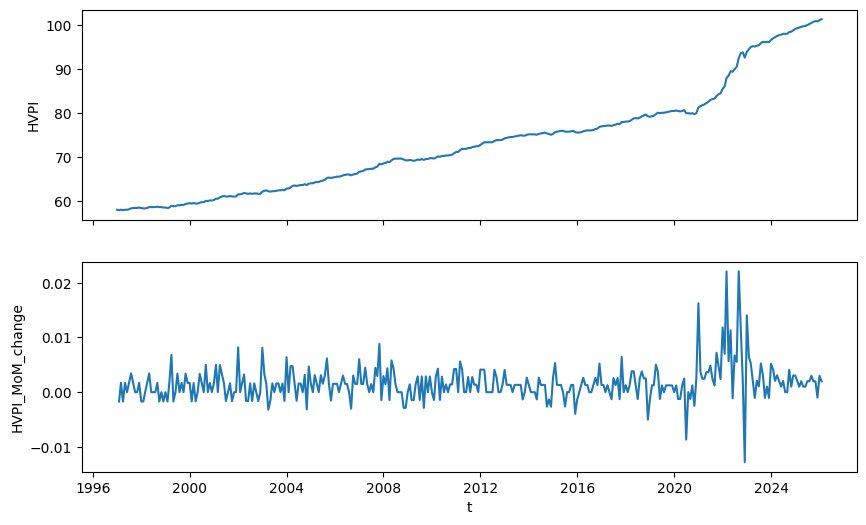

In [43]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/HVPI.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'HVPI'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['HVPI_MoM_change'] = df['HVPI'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'HVPI')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'HVPI_MoM_change')

df = df.drop(columns = 'HVPI')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/HVPI_MoM_change.csv', index=False)

## ifo_bci

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/2736978554.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


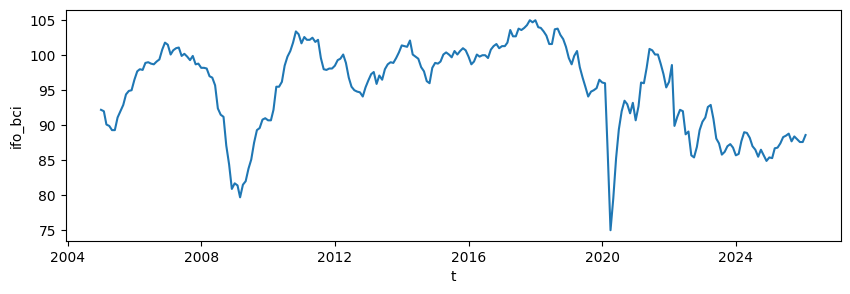

In [44]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/ifo_bci_all.csv',
                 header=None,
                 skiprows=9,
                 usecols=[0, 1],
                 names=['t', 'ifo_bci'],
                 delimiter=';',
                 decimal=','
                 )
df = df.dropna()
df['t'] = pd.to_datetime(df['t'])

plt.figure(figsize = (10, 3))
sns.lineplot(data = df, x = 't', y = 'ifo_bci')

df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/ifo_bci.csv', index=False)

## ifo_bci_manufacturing

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/1499507799.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


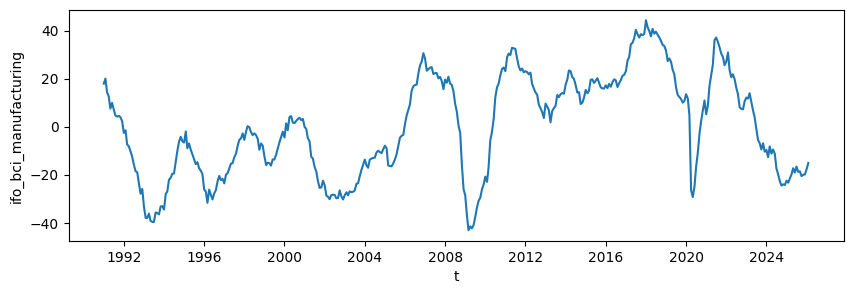

In [45]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/ifo_bci_sectors.csv',
                 header=None,
                 skiprows=9,
                 usecols=[0, 5],
                 names=['t', 'ifo_bci_manufacturing'],
                 delimiter=';',
                 decimal=','
                 )
df = df.dropna()
df['t'] = pd.to_datetime(df['t'])

plt.figure(figsize = (10, 3))
sns.lineplot(data = df, x = 't', y = 'ifo_bci_manufacturing')

df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/ifo_bci_manufacturing.csv', index=False)

## ifo_services

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/3551696816.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


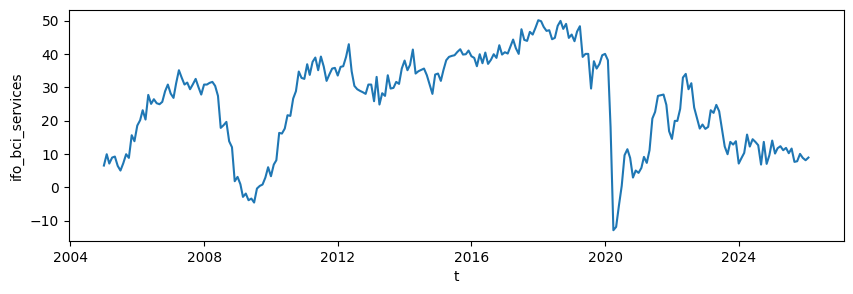

In [46]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/ifo_bci_sectors.csv',
                 header=None,
                 skiprows=9,
                 usecols=[0, 11],
                 names=['t', 'ifo_bci_services'],
                 delimiter=';',
                 decimal=','
                 )
df = df.dropna()
df['t'] = pd.to_datetime(df['t'])

plt.figure(figsize = (10, 3))
sns.lineplot(data = df, x = 't', y = 'ifo_bci_services')

df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/ifo_bci_services.csv', index=False)

## ifo_employment_index

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/133760648.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


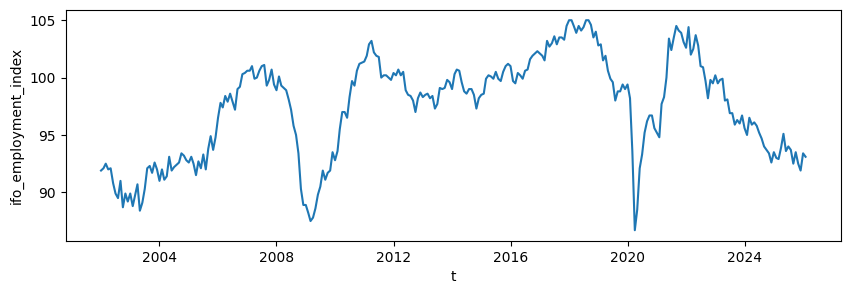

In [47]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/ifo_employment_index.csv',
                 header=None,
                 skiprows=9,
                 usecols=[0, 1],
                 names=['t', 'ifo_employment_index'],
                 delimiter=';',
                 decimal=','
                 )
df = df.dropna()
df['t'] = pd.to_datetime(df['t'])

plt.figure(figsize = (10, 3))
sns.lineplot(data = df, x = 't', y = 'ifo_employment_index')

df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/ifo_employment_index.csv', index=False)

## import_price_index

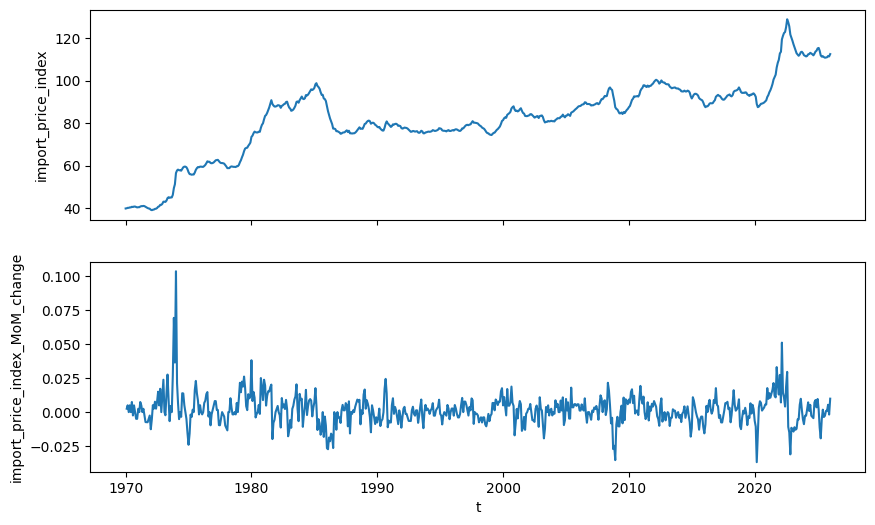

In [48]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/import_price_index.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'import_price_index'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['import_price_index_MoM_change'] = df['import_price_index'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'import_price_index')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'import_price_index_MoM_change')

df = df.drop(columns = 'import_price_index')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/import_price_index_MoM_change.csv', index=False)

## imports

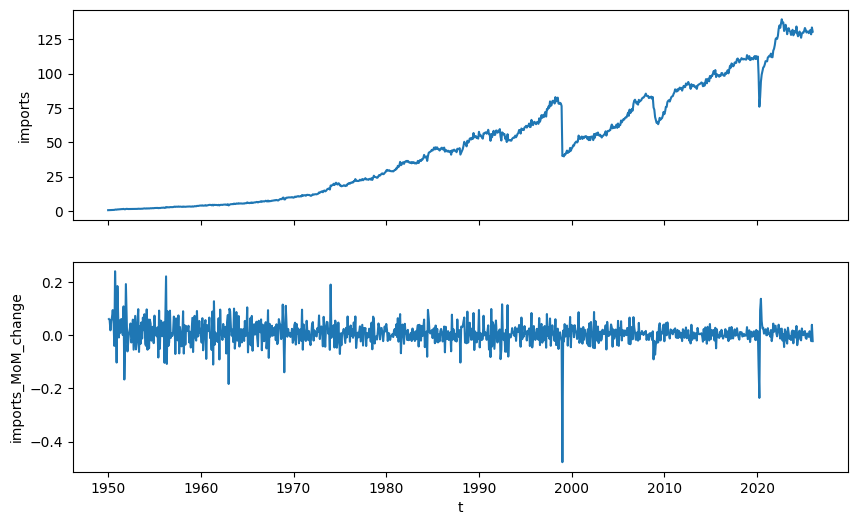

In [49]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/imports.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'imports'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['imports_MoM_change'] = df['imports'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'imports')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'imports_MoM_change')

df = df.drop(columns = 'imports')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/imports_MoM_change.csv', index=False)

## industry_orders

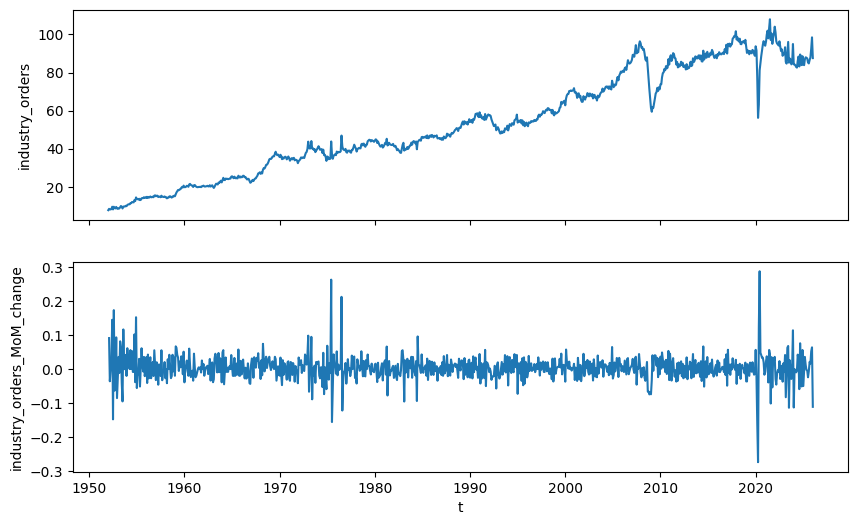

In [50]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/industry_orders.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'industry_orders'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['industry_orders_MoM_change'] = df['industry_orders'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'industry_orders')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'industry_orders_MoM_change')

df = df.drop(columns = 'industry_orders')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/industry_orders_MoM_change.csv', index=False)

## inventories

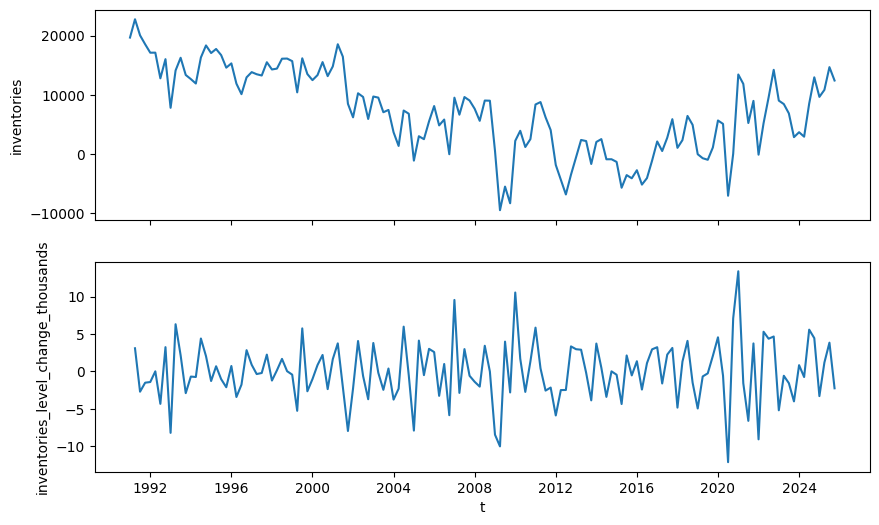

In [51]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/inventories.csv',
                 header=None,
                 skiprows=1,
                 names=['t', 'inventories']
                 )
df['t'] = pd.to_datetime(df['t'])
df['inventories_level_change_thousands'] = df['inventories'].diff() / 1000

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'inventories')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'inventories_level_change_thousands')

df = df.drop(columns = 'inventories')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/inventories_level_change_thousands.csv', index=False)

## job_vacancies

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/3714818855.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


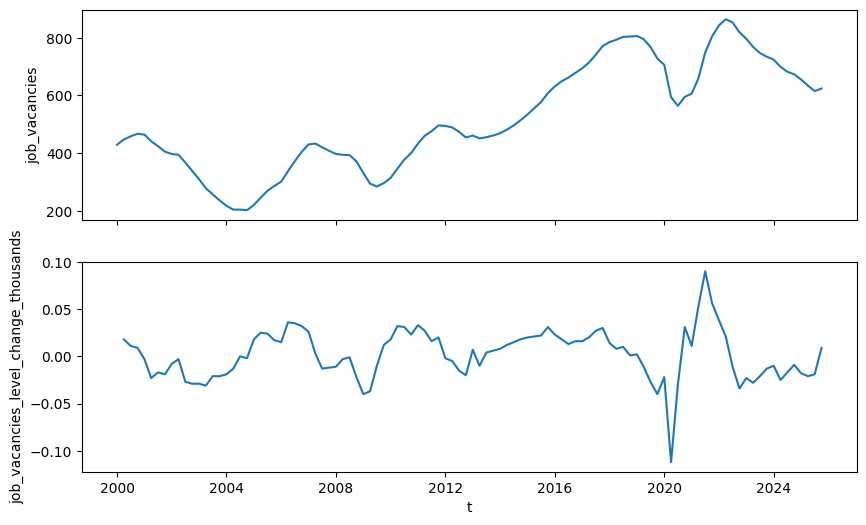

In [52]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/job_vacancies.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'job_vacancies'],
                 delimiter=';'
                 )
df['t'] = pd.to_datetime(df['t'])
df['job_vacancies_level_change_thousands'] = df['job_vacancies'].diff() / 1000

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'job_vacancies')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'job_vacancies_level_change_thousands')

df = df.drop(columns = 'job_vacancies')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/job_vacancies_level_change_thousands.csv', index=False)

## manufacturing_production

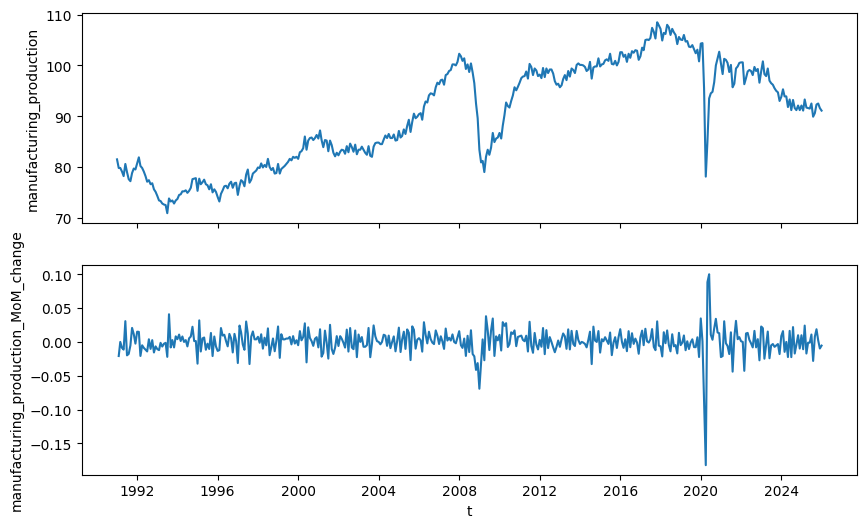

In [53]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/manufacturing_production.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'manufacturing_production'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['manufacturing_production_MoM_change'] = df['manufacturing_production'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'manufacturing_production')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'manufacturing_production_MoM_change')

df = df.drop(columns = 'manufacturing_production')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/manufacturing_production_MoM_change.csv', index=False)

## personal_consumption

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/4131840071.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


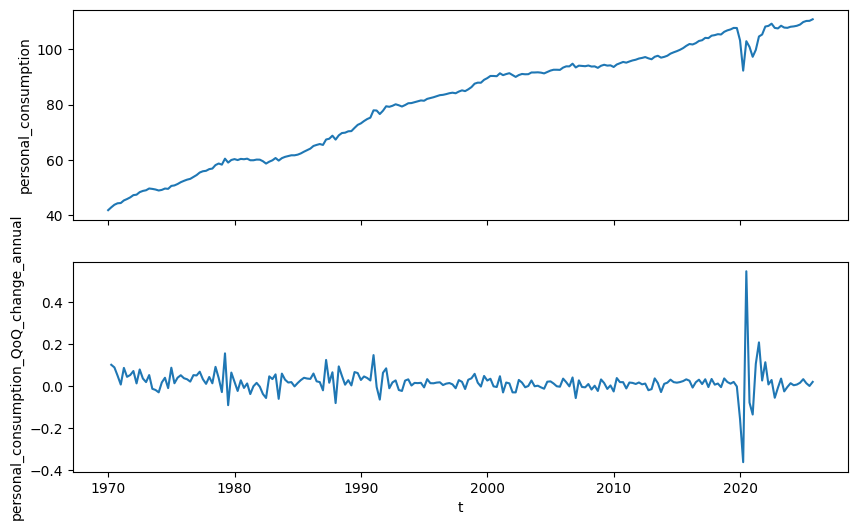

In [54]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/personal_consumption.csv',
                 header=None,
                 skiprows=11,
                 usecols=[0, 1],
                 names=['t', 'personal_consumption'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['personal_consumption_QoQ_change_annual'] = (df['personal_consumption'] / df['personal_consumption'].shift(1))**4 - 1

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'personal_consumption')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'personal_consumption_QoQ_change_annual')

df = df.drop(columns = 'personal_consumption')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/personal_consumption_QoQ_change_annual.csv', index=False)

## producer_price_index

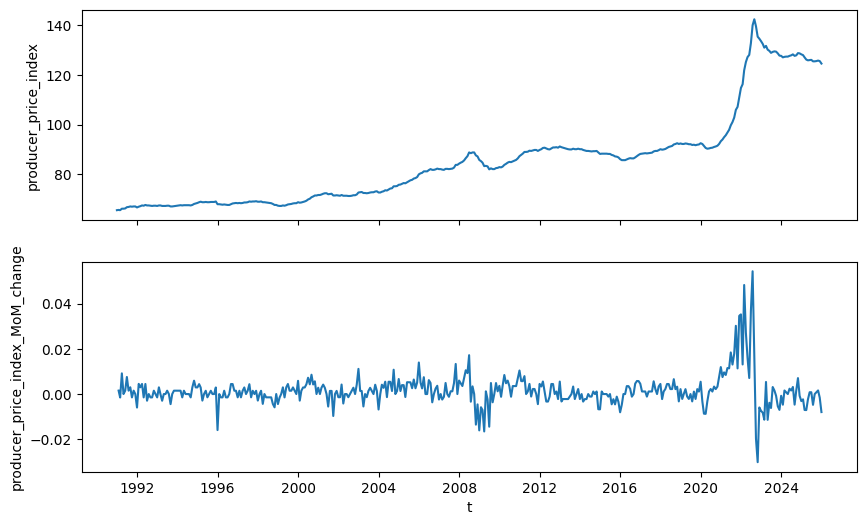

In [55]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/producer_price_index.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'producer_price_index'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['producer_price_index_MoM_change'] = df['producer_price_index'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'producer_price_index')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'producer_price_index_MoM_change')

df = df.drop(columns = 'producer_price_index')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/producer_price_index_MoM_change.csv', index=False)

## retail_sales

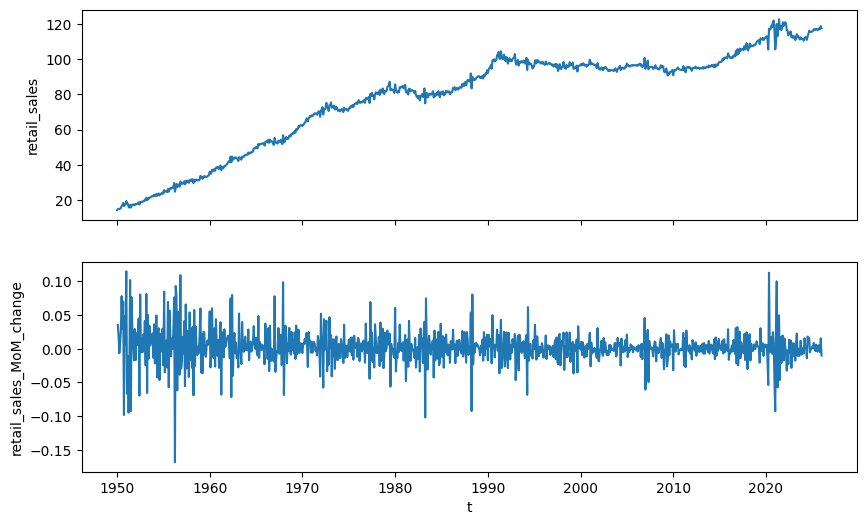

In [56]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/retail_sales.csv',
                 header=None,
                 skiprows=11,
                 usecols=[0, 1],
                 names=['t', 'retail_sales'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['retail_sales_MoM_change'] = df['retail_sales'].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'retail_sales')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'retail_sales_MoM_change')

df = df.drop(columns = 'retail_sales')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/retail_sales_MoM_change.csv', index=False)

## unemployment_rate

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/688371564.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


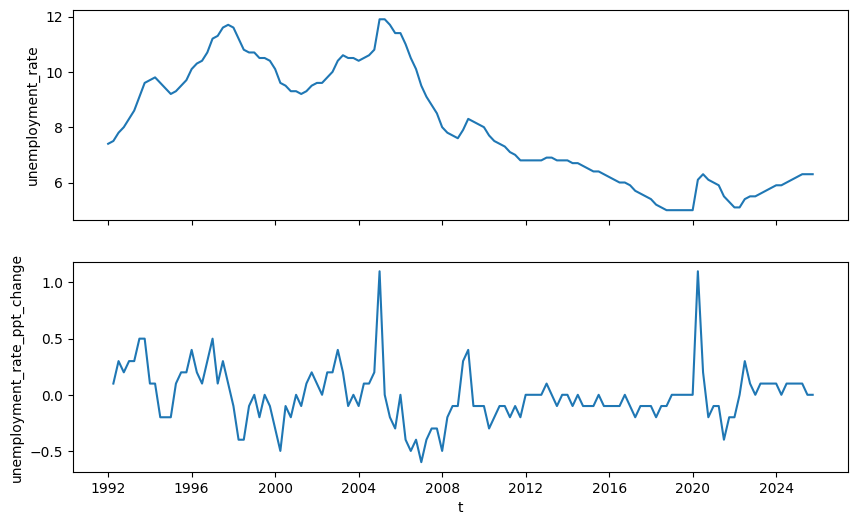

In [57]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/unemployment_rate.csv',
                 header=None,
                 skiprows=10,
                 usecols=[0, 1],
                 names=['t', 'unemployment_rate'],
                 delimiter=';',
                 decimal=','
                 )
df['t'] = pd.to_datetime(df['t'])
df['unemployment_rate_ppt_change'] = df['unemployment_rate'].diff()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'unemployment_rate')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'unemployment_rate_ppt_change')

df = df.drop(columns = 'unemployment_rate')
df = df.dropna()

df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/unemployment_rate_ppt_change.csv', index=False)

## unit_labor_costs

/var/folders/wk/66pqj14s5h9gslqvv7sc4n_40000gn/T/ipykernel_23023/2006704585.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['t'] = pd.to_datetime(df['t'])


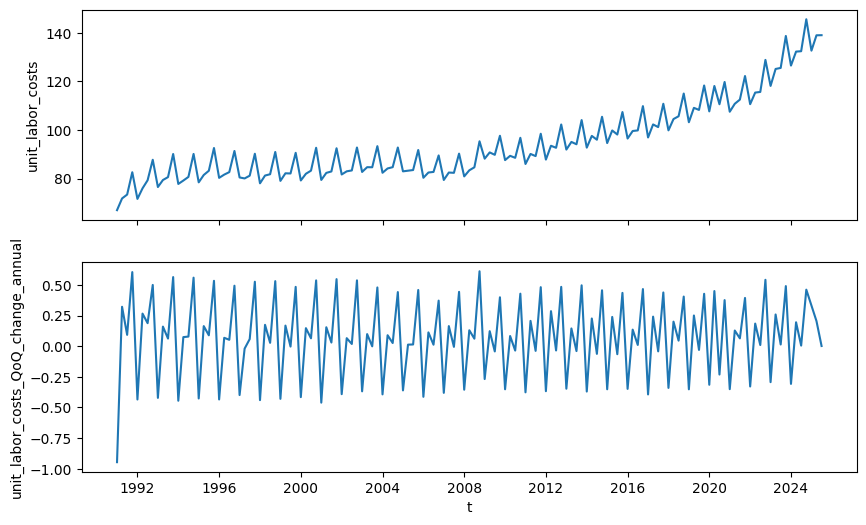

In [58]:
df = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Raw/unit_labor_costs.csv',
                 header=None,
                 skiprows=1,
                 usecols=[22, 24],
                 names=['t', 'unit_labor_costs'],
                 )
df['t'] = pd.to_datetime(df['t'])
df['unit_labor_costs_QoQ_change_annual'] = (df['unit_labor_costs'] / df['unit_labor_costs'].shift(1))**4 - 1

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.lineplot(ax=axes[0], data = df, x = 't', y = 'unit_labor_costs')
sns.lineplot(ax=axes[1], data = df, x = 't', y = 'unit_labor_costs_QoQ_change_annual')

df = df.drop(columns = 'unit_labor_costs')
df = df.dropna()
df.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/unit_labor_costs_QoQ_change_annual.csv', index=False)

# create combined data set

In [59]:
def stack_monthly(df):
    """convert monthly series to quarterly wide format (m1, m2, m3)"""

    df = df.sort_values('t')
    value_col = df.columns.drop('t')[0]

    if df['t'].dt.to_period('M').nunique() > 1.5 * df['t'].dt.to_period('Q').nunique():

        df['q'] = df['t'].dt.to_period('Q')
        df['m'] = (df['t'].dt.month - 1) % 3 + 1

        df = (
            df.pivot_table(index='q', columns='m', values=value_col)
              .reindex(columns=[1, 2, 3])
        )

        df.columns = [f'{value_col}_m{i}' for i in [1, 2, 3]]
        df = df.reset_index()

        df['t'] = df['q'].dt.to_timestamp(how='start')
        return df.drop(columns='q')

    return df

def align_time_index(df, target):
    """align df to quarterly timeline of target"""
    timeline = pd.DataFrame({
        't': pd.date_range(target['t'].min(), target['t'].max(), freq='QS')
    })
    return timeline.merge(df, on='t', how='left')

def add_data(df, target):
    """left-merge features into target"""
    return target.merge(df, on='t', how='left')

In [60]:
files = [
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/construction_level_change_thousands.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/construction_value_added_QoQ_change_annual.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/disposable_personal_QoQ_change_annual.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/employees_level_change_thousands.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/export_price_index_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/exports_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/GDI_QoQ_change_annual.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/HVPI_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/HVPI_wo_food_energy_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/ifo_bci_manufacturing.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/ifo_bci_services.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/ifo_bci.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/ifo_employment_index.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/import_price_index_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/imports_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/industry_orders_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/inventories_level_change_thousands.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/job_vacancies_level_change_thousands.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/manufacturing_production_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/personal_consumption_QoQ_change_annual.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/producer_price_index_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/retail_sales_MoM_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/unemployment_rate_ppt_change.csv',
    '/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/unit_labor_costs_QoQ_change_annual.csv'    
]

In [61]:
data = pd.read_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/GDP_QoQ_change.csv')
data['t'] = pd.to_datetime(data['t'])

for file in files:

    df = pd.read_csv(file)

    df['t'] = pd.to_datetime(df['t'])

    df = stack_monthly(df)

    df = align_time_index(df, data)

    data = add_data(df, data)

data.to_csv('/Users/mats/Documents/Uni/Kursdateien/Bachelor Thesis/02_Data/Preprocessed/all_data_combined.csv', index=False)

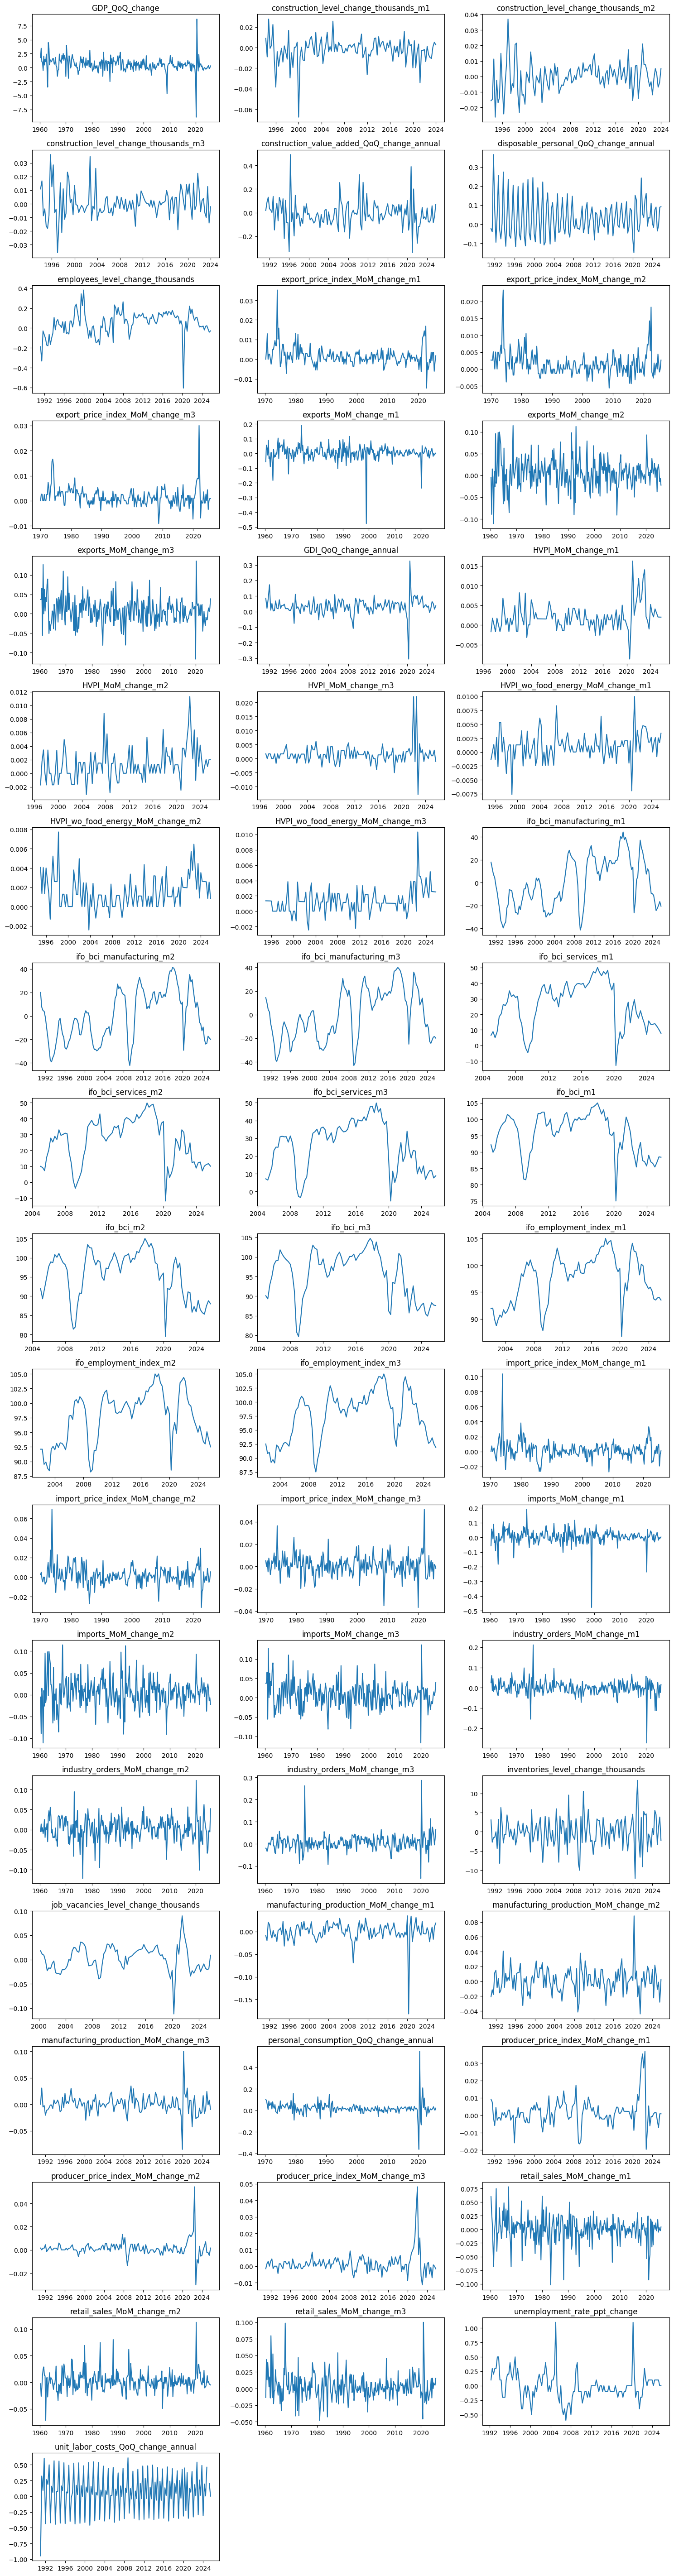

In [62]:
cols = [c for c in data.columns if c != "t"]
n = len(cols)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows))
axes = axes.flatten()

for i, c in enumerate(cols):
    axes[i].plot(data["t"], data[c])
    axes[i].set_title(c)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()